In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install pycocotools matplotlib opencv-python


loading annotations into memory...
Done (t=1.52s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-34504444.py:33: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=40, max_width=40, p=0.3)


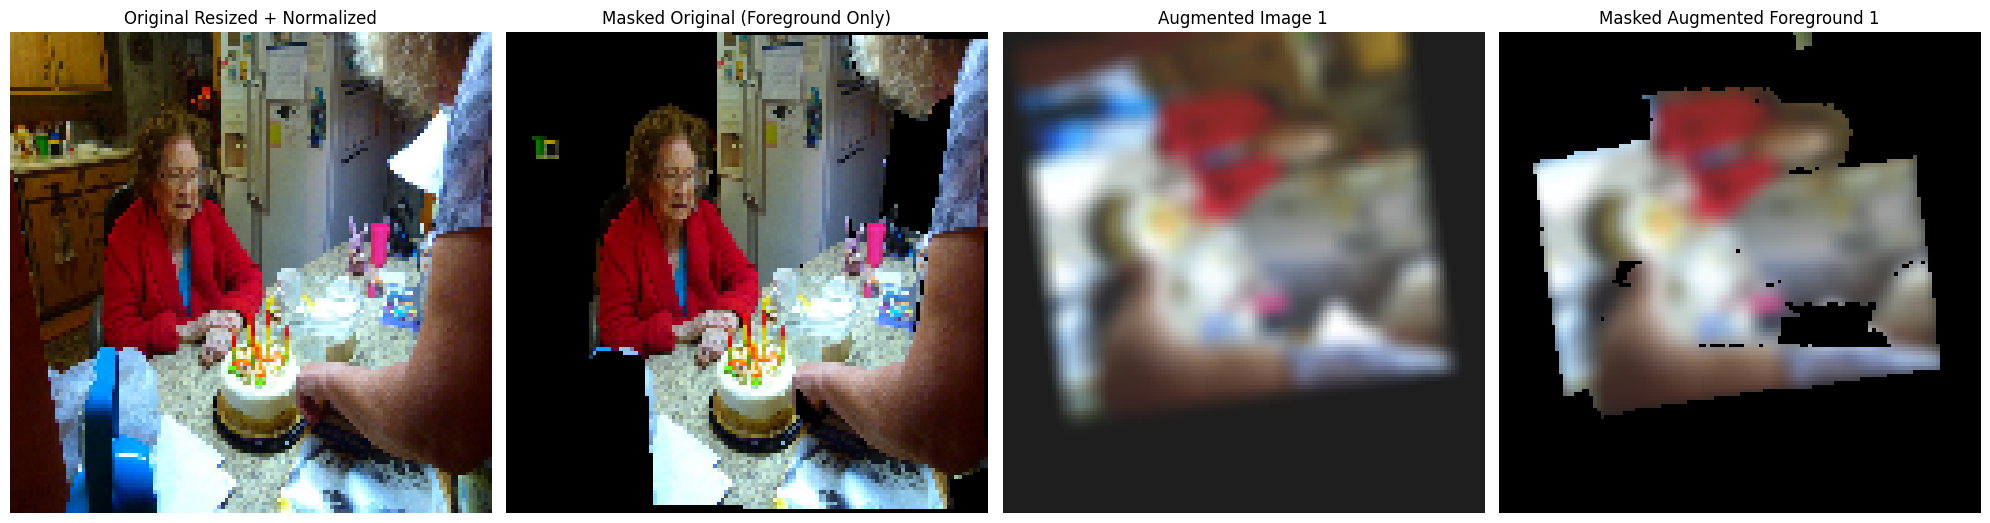

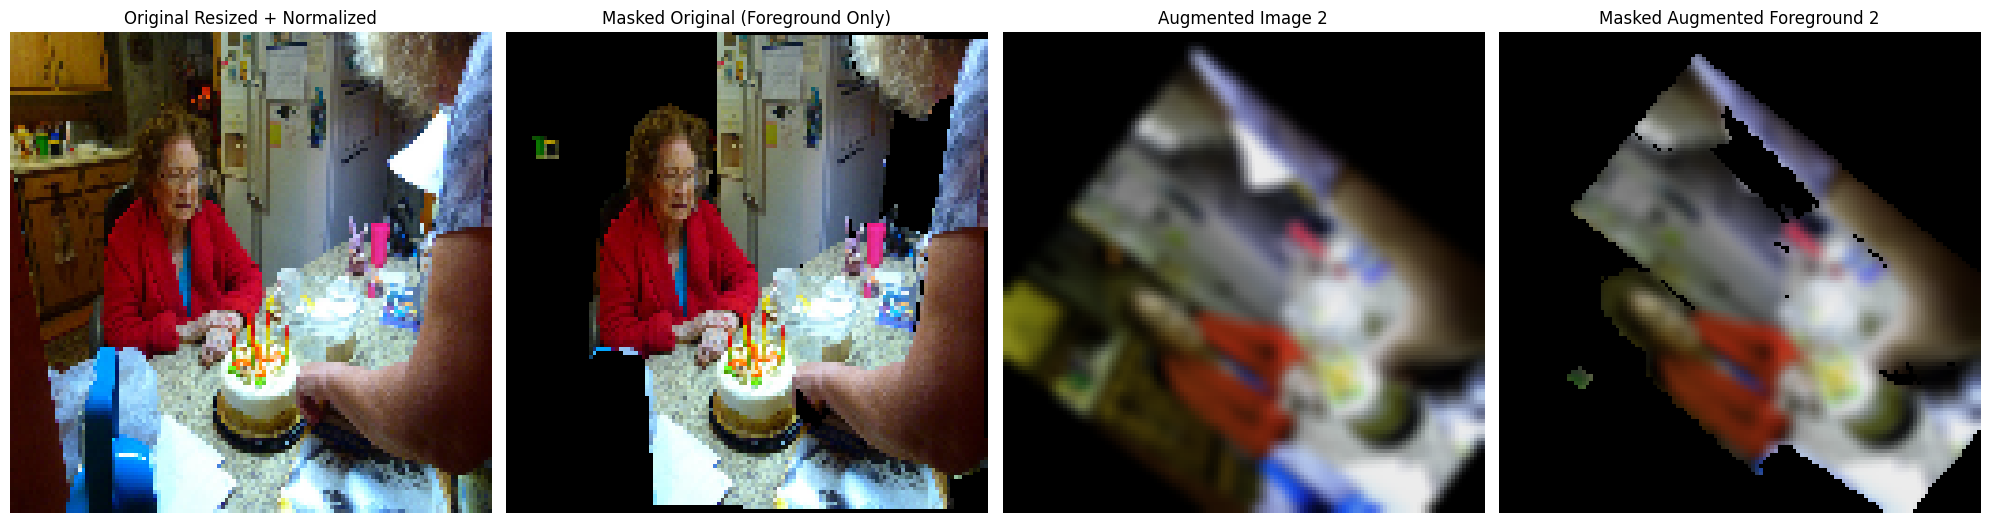

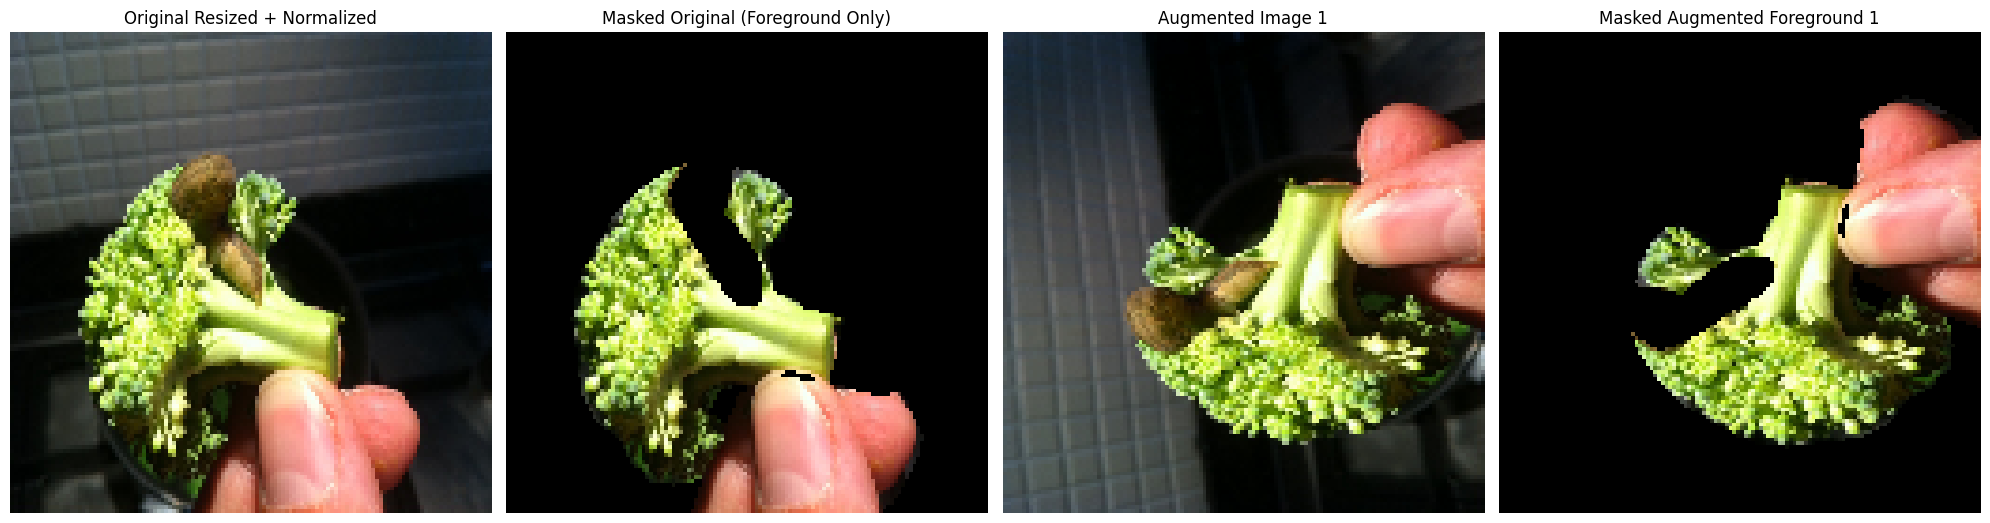

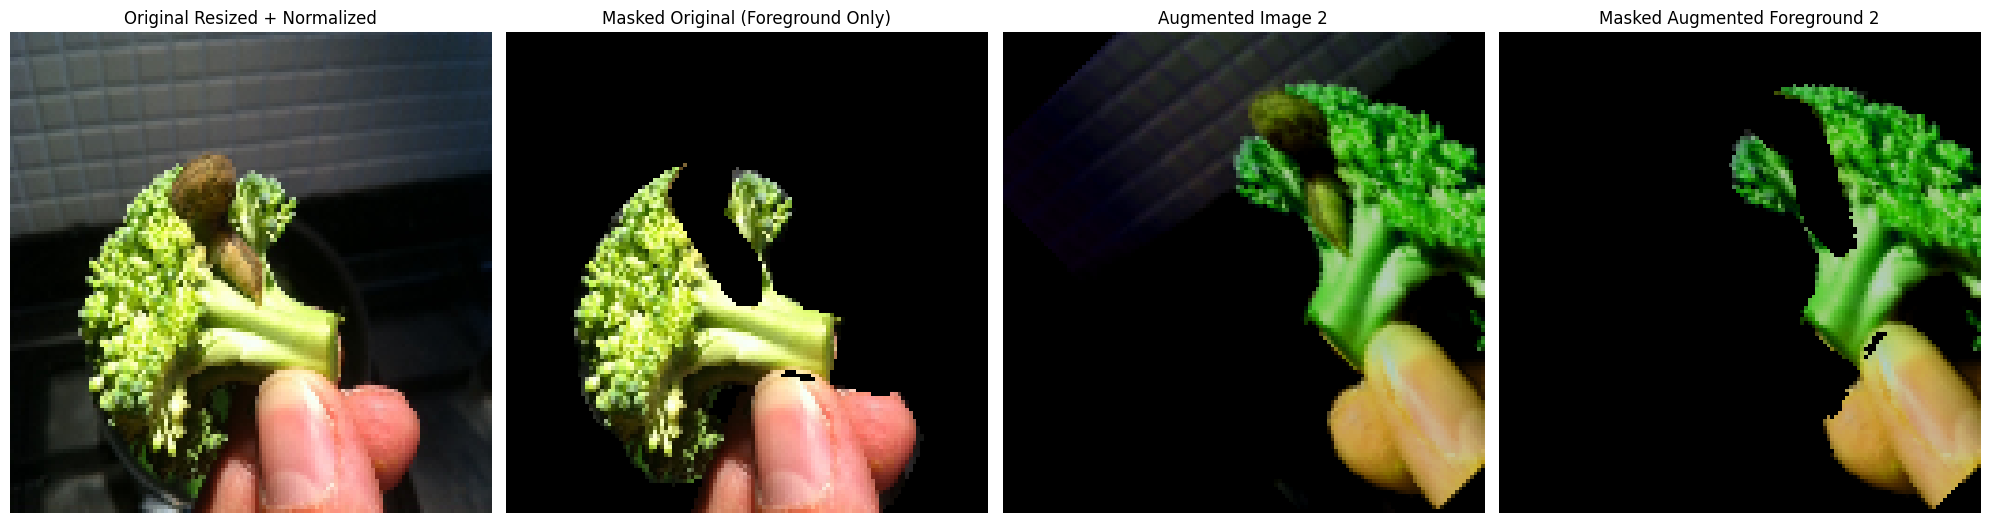

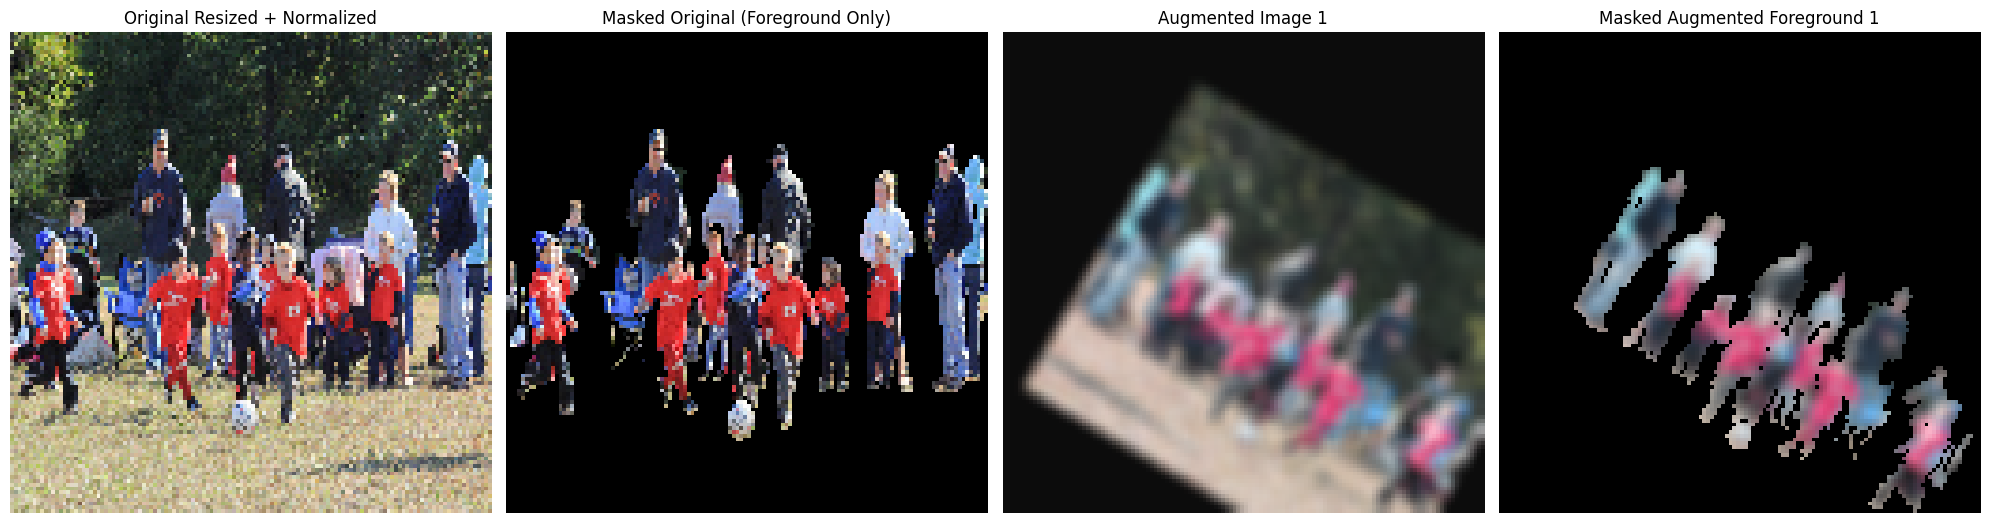

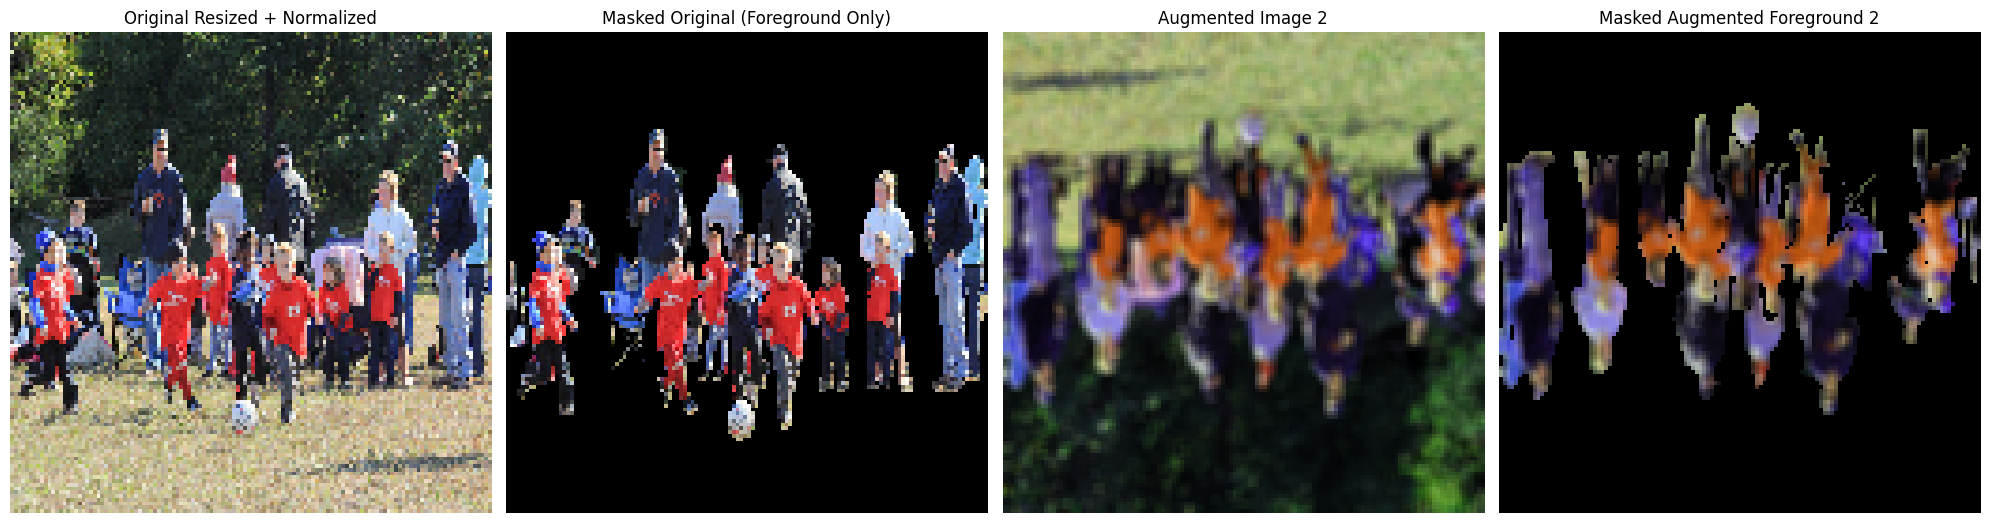

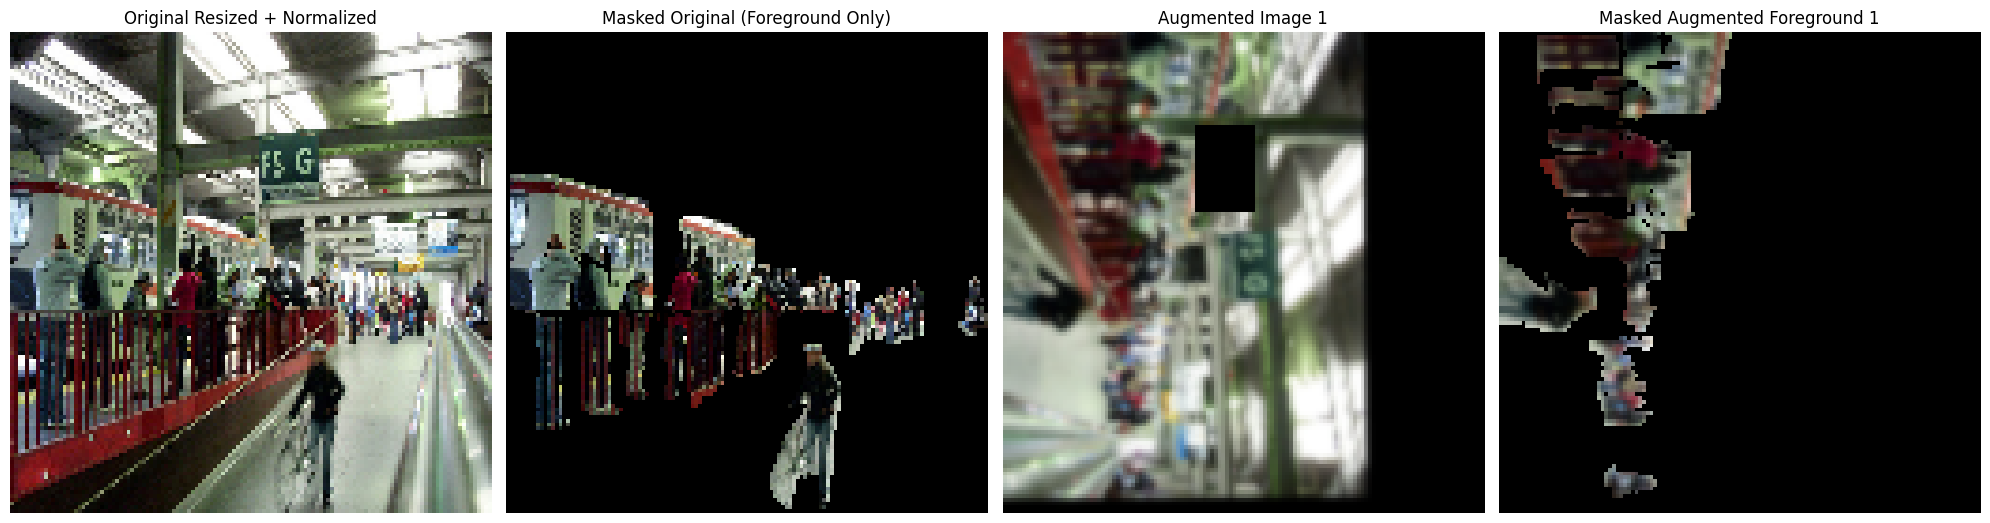

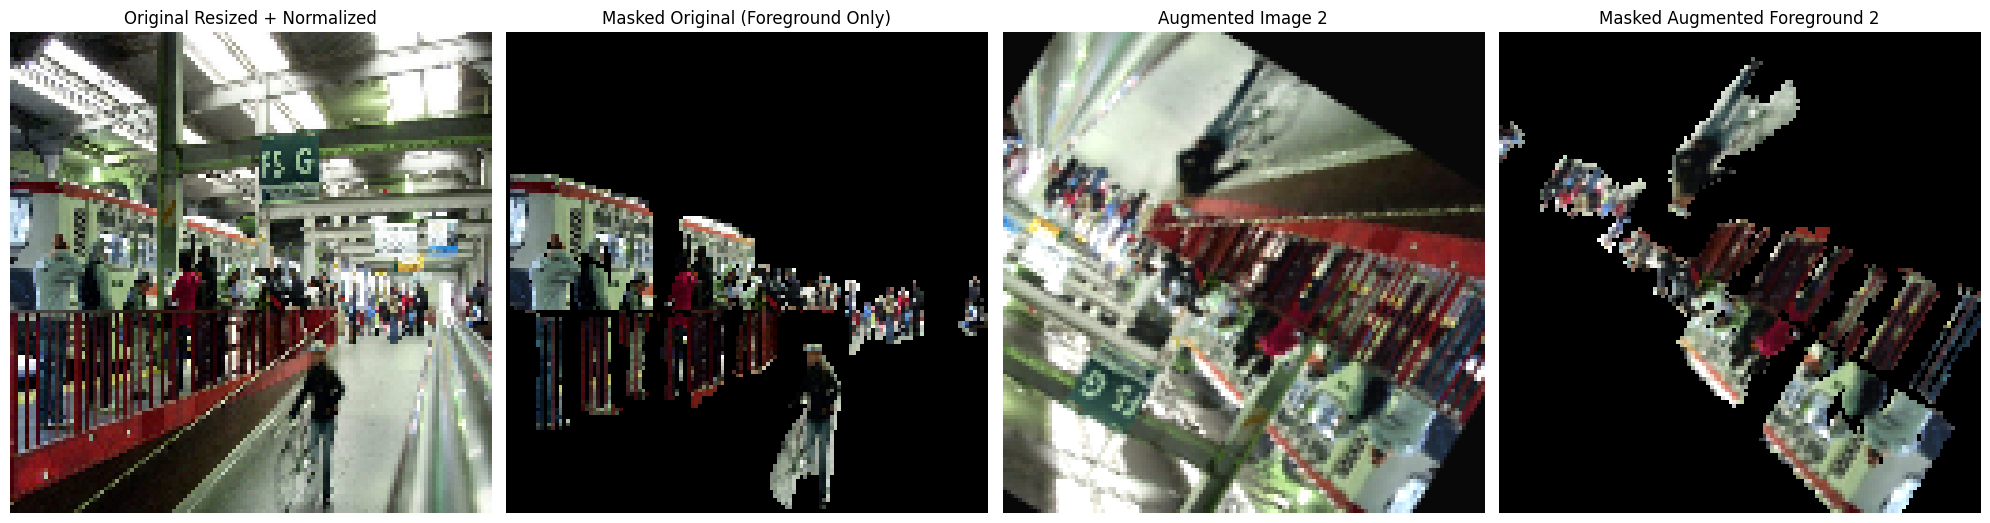

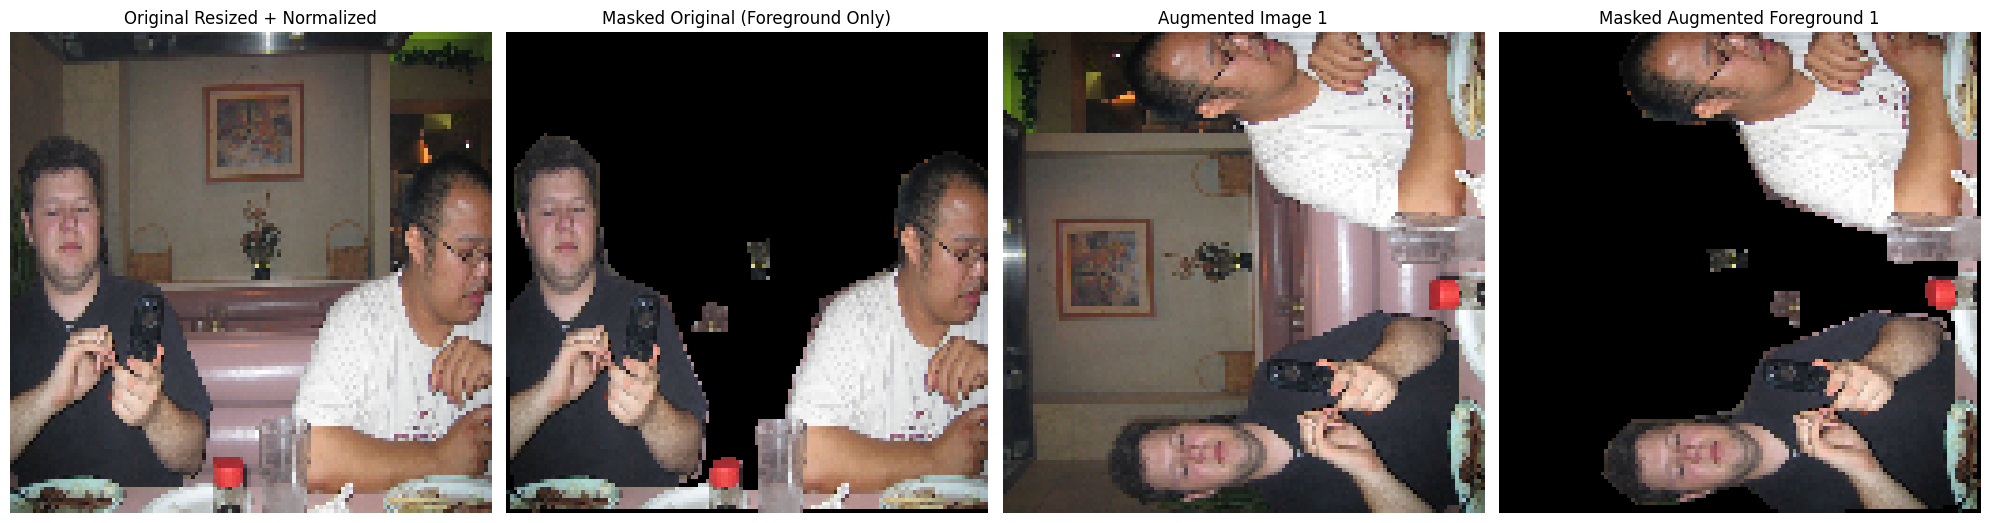

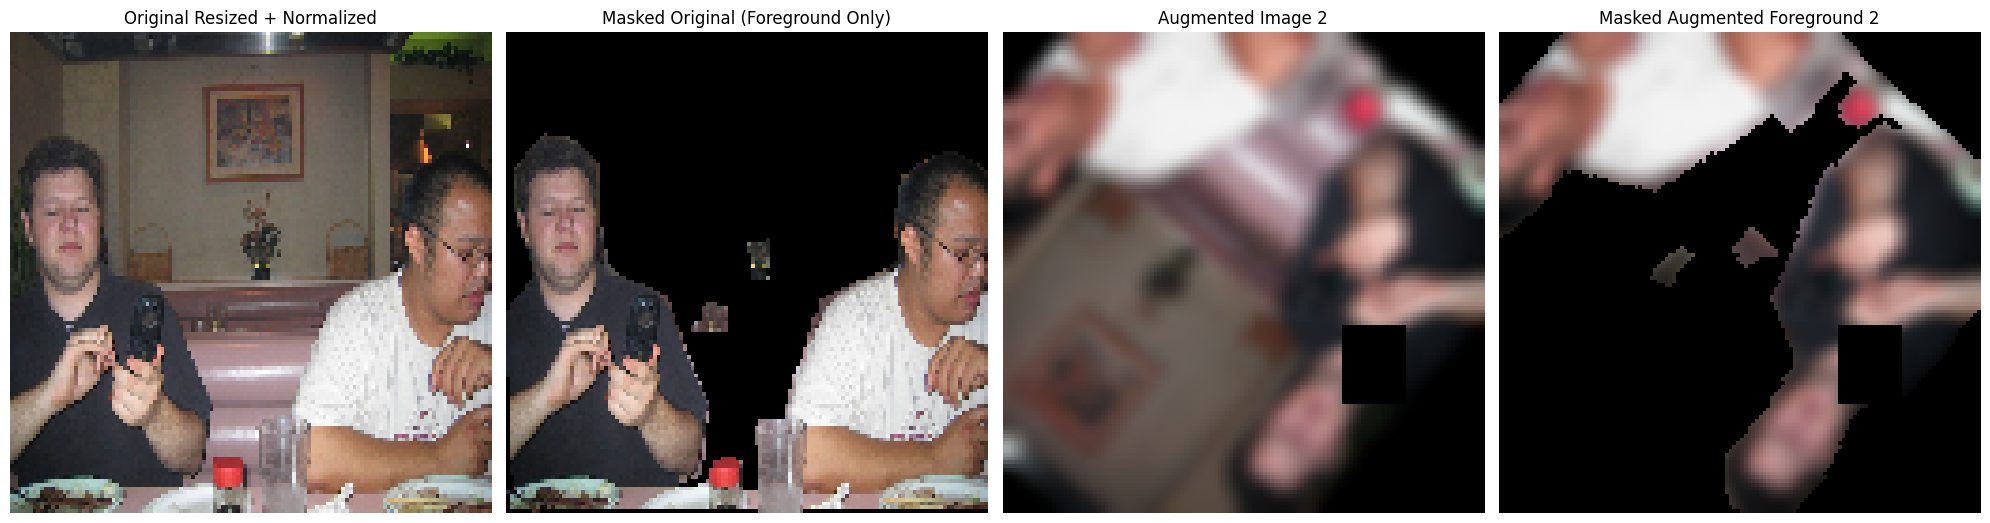

In [10]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pycocotools.coco import COCO
import albumentations as A

# === Configuration ===
IMG_DIR = "/content/drive/MyDrive/Colab Notebooks/Vision Extract/val2017"
ANN_FILE = "/content/drive/MyDrive/Colab Notebooks/Vision Extract/val2017/annotations/instances_val2017.json"
NUM_IMAGES = 5
AUG_ROUNDS = 2
RESIZE_DIM = 128  # Reduced for smaller image size

# === Load COCO Dataset ===
coco = COCO(ANN_FILE)
img_ids = coco.getImgIds()
random.shuffle(img_ids)
sample_img_ids = img_ids[:NUM_IMAGES]

# === Define Augmentation Pipeline ===
transform = A.Compose([
    A.Resize(RESIZE_DIM, RESIZE_DIM),
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.3, rotate_limit=60, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.4),
    A.RandomGamma(p=0.4),
    A.CoarseDropout(max_holes=8, max_height=40, max_width=40, p=0.3)
])

# === Processing Loop ===
for idx, img_id in enumerate(sample_img_ids, 1):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMG_DIR, img_info['file_name'])

    # Load and validate image
    image = cv2.imread(img_path)
    if image is None:
        print(f"⚠️ Warning: Could not load image {img_path}")
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load annotations and build mask
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    for ann in anns:
        mask |= coco.annToMask(ann).astype(np.uint8)

    # Resize and normalize original image and mask
    image_resized = cv2.resize(image, (RESIZE_DIM, RESIZE_DIM)).astype(np.float32) / 255.0
    mask_resized = cv2.resize(mask, (RESIZE_DIM, RESIZE_DIM), interpolation=cv2.INTER_NEAREST)

    # Masked original image
    masked_original = image_resized.copy()
    masked_original[mask_resized == 0] = 0

    # === Augmentation Loop ===
    for aug_idx in range(AUG_ROUNDS):
        augmented = transform(image=image, mask=mask)
        aug_img = augmented["image"]
        aug_mask = augmented["mask"]

        # Normalize augmented image
        aug_img_norm = aug_img.astype(np.float32) / 255.0

        # Masked augmented image
        aug_masked = aug_img_norm.copy()
        aug_masked[aug_mask == 0] = 0

        # === Visualization ===
        fig, axes = plt.subplots(1, 4, figsize=(20, 6))
        titles = [
            "Original Resized + Normalized",
            "Masked Original (Foreground Only)",
            f"Augmented Image {aug_idx + 1}",
            f"Masked Augmented Foreground {aug_idx + 1}"
        ]
        images = [image_resized, masked_original, aug_img_norm, aug_masked]

        for ax, img, title in zip(axes, images, titles):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis("off")

        plt.tight_layout()
        plt.show()